# **Install yfinance**

In [1]:
!pip install yfinance

# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Stock Data Load**

In [3]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_1610/534828021.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


# **Data Visualization**

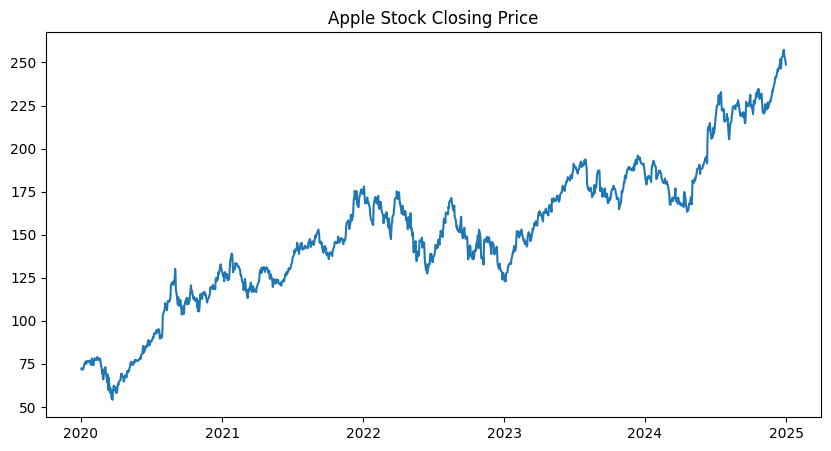

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price")
plt.show()

# **Feature Selection**

In [5]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]

df.dropna(inplace=True)

# **Define X and Y**

In [6]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# **Train Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Train Model**

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Prediction**

In [9]:
y_pred = model.predict(X_test)

# **Evaluation**

In [10]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.741878320680934
RMSE: 0.9982197018233627
R2 Score: 0.9994242482194574


# **Actual vs Predicted Graph**

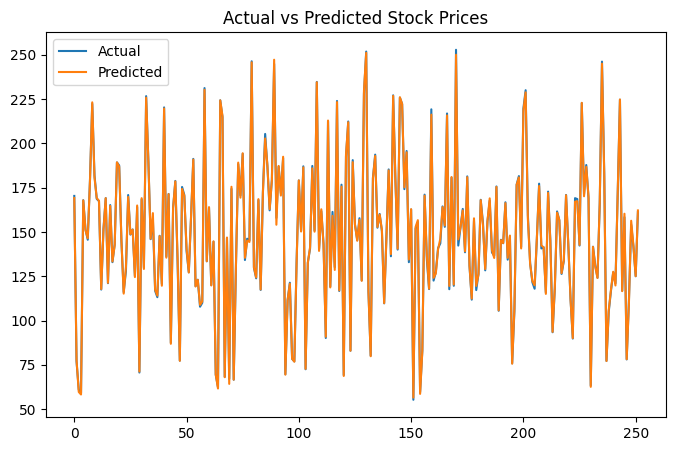

In [11]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()

# Task 2: Stock Price Prediction

## Conclusion

A Linear Regression model was developed to predict Apple stock closing prices using historical market data such as Open, High, Low, and Volume.

## Results
- Mean Absolute Error (MAE): 0.74
- Root Mean Squared Error (RMSE): 0.99
- R² Score: 0.9994

## Key Findings
- The model achieved extremely high accuracy in predicting stock prices.
- Strong correlation exists between Open, High, Low, and Close prices.
- Linear Regression performed very well on this dataset due to stable market patterns.

## Final Insight
The model demonstrates that short-term stock price prediction using historical OHLC data can be highly accurate under controlled conditions, though real-world markets may introduce more randomness.